In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (8,5)

In [17]:
# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


In [18]:
# Load the dataset
df = pd.read_csv('activity-detection.csv')

# Display shape
print("Dataset Shape:", df.shape)

# Display first 5 rows
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (10299, 563)

First 5 rows:


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [19]:
# Dataset info
print("Dataset Info:")
print(df.info())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum().sum())

# Display class distribution
print("\nClass Distribution:")
print(df['Activity'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10299 entries, 0 to 10298
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 44.2+ MB
None

Missing Values:
0

Class Distribution:
Activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64


In [20]:
# Separate features and target
X = df.drop('Activity', axis=1)
y = df['Activity']

print("Features (X) shape:", X.shape)
print("Target  (y) shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Features (X) shape: (10299, 562)
Target  (y) shape: (10299,)

Feature columns:
['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X', 'tBodyAcc-max()-Y', 'tBodyAcc-max()-Z', 'tBodyAcc-min()-X', 'tBodyAcc-min()-Y', 'tBodyAcc-min()-Z', 'tBodyAcc-sma()', 'tBodyAcc-energy()-X', 'tBodyAcc-energy()-Y', 'tBodyAcc-energy()-Z', 'tBodyAcc-iqr()-X', 'tBodyAcc-iqr()-Y', 'tBodyAcc-iqr()-Z', 'tBodyAcc-entropy()-X', 'tBodyAcc-entropy()-Y', 'tBodyAcc-entropy()-Z', 'tBodyAcc-arCoeff()-X,1', 'tBodyAcc-arCoeff()-X,2', 'tBodyAcc-arCoeff()-X,3', 'tBodyAcc-arCoeff()-X,4', 'tBodyAcc-arCoeff()-Y,1', 'tBodyAcc-arCoeff()-Y,2', 'tBodyAcc-arCoeff()-Y,3', 'tBodyAcc-arCoeff()-Y,4', 'tBodyAcc-arCoeff()-Z,1', 'tBodyAcc-arCoeff()-Z,2', 'tBodyAcc-arCoeff()-Z,3', 'tBodyAcc-arCoeff()-Z,4', 'tBodyAcc-correlation()-X,Y', 'tBodyAcc-correlation()-X,Z', 'tBodyAcc-correlation()-Y,

In [21]:
# --------------------------------------------------------------------------
# First split  →  60% Train  |  40% Temp (Validation + Test)
# --------------------------------------------------------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

# --------------------------------------------------------------------------
# Second split  →  Temp split equally into 20% Validation | 20% Test
# --------------------------------------------------------------------------
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

# Print sizes
print("Split Summary:")
print(f"  Training set  : {X_train.shape[0]} samples  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation set: {X_val.shape[0]} samples   ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set      : {X_test.shape[0]} samples   ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify stratification – class-wise counts
print("\nClass distribution per split:")
print(f"  Train :  {y_train.value_counts().sort_index().tolist()}")
print(f"  Val   :  {y_val.value_counts().sort_index().tolist()}")
print(f"  Test  :  {y_test.value_counts().sort_index().tolist()}")

Split Summary:
  Training set  : 6179 samples  (60.0%)
  Validation set: 2060 samples   (20.0%)
  Test set      : 2060 samples   (20.0%)

Class distribution per split:
  Train :  [1166, 1066, 1144, 1033, 844, 926]
  Val   :  [389, 355, 381, 345, 281, 309]
  Test  :  [389, 356, 381, 344, 281, 309]


In [22]:
# Re-attach the Class label before saving
train_df = pd.concat([X_train, y_train], axis=1)
val_df  = pd.concat([X_val,   y_val],   axis=1)
test_df = pd.concat([X_test,  y_test],  axis=1)

# Save to CSV
train_df.to_csv('ActivityTrain.csv',       index=False)
val_df.to_csv('ActivityValidation.csv',    index=False)
test_df.to_csv('ActivityTest.csv',         index=False)

print("CSV files saved successfully:")
print(f"  ✓ ActivityTrain.csv        – {train_df.shape}")
print(f"  ✓ ActivityValidation.csv   – {val_df.shape}")
print(f"  ✓ ActivityTest.csv         – {test_df.shape}")

CSV files saved successfully:
  ✓ ActivityTrain.csv        – (6179, 563)
  ✓ ActivityValidation.csv   – (2060, 563)
  ✓ ActivityTest.csv         – (2060, 563)


In [24]:
df_train = pd.read_csv('ActivityTrain.csv')

# Display shape
print("Dataset Shape:", df_train.shape)

# Display first 5 rows
print("\nFirst 5 rows:")
df_train.head()

Dataset Shape: (6179, 563)

First 5 rows:


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.321443,-0.023799,-0.119695,-0.336548,-0.183307,-0.154297,-0.396342,-0.224409,-0.220786,-0.073510,...,-0.563389,-0.874477,-0.684506,-0.948809,0.472612,-0.677946,0.256877,0.177768,24,WALKING_UPSTAIRS
1,0.217472,0.011115,-0.115445,-0.414603,-0.184887,-0.397835,-0.452784,-0.178431,-0.396061,-0.330133,...,-0.550507,0.571962,0.354293,0.925243,-0.287186,-0.755529,0.250761,0.092332,28,WALKING
2,0.282537,-0.018321,-0.112263,-0.993073,-0.978583,-0.986129,-0.993825,-0.979682,-0.985791,-0.938877,...,-0.784398,0.033368,0.017298,0.038035,-0.109415,-0.313999,-0.206129,-0.337052,27,SITTING
3,0.318016,-0.001377,-0.130748,-0.315958,0.073095,0.013274,-0.358730,0.092175,0.004789,-0.253829,...,0.024109,-0.379363,0.516752,-0.010637,0.692445,-0.627893,0.262993,0.219719,13,WALKING
4,0.276054,-0.015739,-0.108058,-0.997684,-0.994767,-0.991306,-0.998274,-0.993481,-0.991073,-0.941739,...,-0.898185,0.104284,0.066120,-0.069277,0.277116,-0.600329,-0.037652,-0.232059,20,SITTING


In [40]:
# Standardization
scaler_std = StandardScaler()
standardized_train = scaler_std.fit_transform(X_train)
standardized_df = pd.DataFrame(standardized_train,columns=X_train.columns)
standardized_Activity = pd.concat([standardized_df,y_train])


standardized_Activity.to_csv('ActivityScaledTrain.csv', index=False)

In [41]:
df_test = pd.read_csv('ActivityTest.csv')

# Display shape
print("Dataset Shape:", df_test.shape)

# Display first 5 rows
print("\nFirst 5 rows:")
df_test.head()

Dataset Shape: (2060, 563)

First 5 rows:


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.262335,-0.016571,-0.129386,-0.958088,-0.942715,-0.874138,-0.959476,-0.944177,-0.862660,-0.906879,...,-0.894957,0.540134,-0.214432,0.200990,0.055670,0.314838,-0.392671,-0.565283,21,LAYING
1,0.277980,-0.017221,-0.107611,-0.990718,-0.991544,-0.993643,-0.991481,-0.990867,-0.993016,-0.935941,...,-0.822000,-0.238645,0.438419,0.205194,-0.778430,0.620486,-0.580947,-0.422423,20,LAYING
2,0.257499,-0.013761,-0.114958,-0.937640,-0.948448,-0.919996,-0.945800,-0.953737,-0.932365,-0.911543,...,-0.426052,0.012100,-0.536836,0.236346,0.519275,0.581271,-0.529296,-0.476615,24,LAYING
3,0.270479,-0.024814,-0.101021,-0.952426,-0.886185,-0.779465,-0.964196,-0.887124,-0.754986,-0.857205,...,-0.653112,0.201026,0.049758,0.102865,-0.055245,-0.999380,0.096644,0.020358,23,STANDING
4,0.215460,-0.004817,-0.095551,-0.349793,-0.244763,-0.078958,-0.397330,-0.299333,-0.123694,-0.248806,...,-0.700301,0.726799,0.589957,0.869086,-0.265442,-0.866184,0.189920,0.005353,30,WALKING


In [47]:
standardized = scaler_std.transform(X_test)
standardized_df=pd.DataFrame(standardized,columns=X_train.columns)
standardized_Activity = pd.concat([standardized_df,y_test])

standardized_Activity.to_csv('ActivityScaledTest.csv', index=False)

In [48]:
df_valid = pd.read_csv('ActivityValidation.csv')

# Display shape
print("Dataset Shape:", df_valid.shape)

# Display first 5 rows
print("\nFirst 5 rows:")
df_valid.head()

Dataset Shape: (2060, 563)

First 5 rows:


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.277739,-0.016598,-0.105260,-0.994653,-0.956947,-0.982800,-0.995371,-0.960453,-0.982714,-0.934544,...,-0.501279,0.023978,-0.142007,0.799813,-0.873749,-0.854670,0.197552,0.033214,27,STANDING
1,0.280580,-0.020204,-0.102516,-0.963065,-0.967258,-0.982854,-0.963110,-0.967299,-0.985335,-0.915285,...,-0.506306,-0.080473,0.321119,-0.027440,0.082104,0.601148,-0.415691,-0.594744,12,LAYING
2,0.282814,-0.016686,-0.110004,-0.994285,-0.973997,-0.988410,-0.994069,-0.978087,-0.989570,-0.938192,...,-0.366579,0.072845,-0.622912,-0.090463,0.313810,0.592963,-0.576030,-0.428127,19,LAYING
3,0.277558,-0.028122,-0.115191,-0.995322,-0.972571,-0.987076,-0.996573,-0.972970,-0.987699,-0.939912,...,-0.774033,-0.047003,0.010963,-0.360400,0.687395,-0.808781,0.195025,-0.075765,19,STANDING
4,0.279001,-0.017959,-0.100549,-0.994335,-0.988911,-0.975375,-0.995061,-0.988896,-0.972142,-0.936691,...,-0.909426,-0.051700,-0.032132,-0.028309,-0.506101,0.323256,-0.760294,-0.143762,15,LAYING


In [49]:
standardized = scaler_std.transform(X_val)
standardized_df = pd.DataFrame(standardized,columns=X_train.columns)
standardized_Activity = pd.concat([standardized_df,y_val])

standardized_Activity.to_csv('ActivityScaledValidation.csv', index=False)

In [52]:
#PCA
pca = PCA()

X_train_all_pca = pca.fit_transform(X_train)
X_valid_all_pca = pca.transform(X_val)
X_test_all_pca = pca.transform(X_test)

X_train_all_pca_df = pd.DataFrame(X_train_all_pca)
X_valid_all_pca_df = pd.DataFrame(X_valid_all_pca)
X_test_all_pca_df = pd.DataFrame(X_test_all_pca)

X_train_all_pca_df.to_csv('ActivityPCAAllTrain.csv', index=False)
X_valid_all_pca_df.to_csv('ActivityPCAAllValidation.csv', index=False)
X_test_all_pca_df.to_csv('ActivityPCAAllTest.csv', index=False)

In [53]:
pca_95 = PCA(n_components=0.95)

X_train_pca_95 = pca_95.fit_transform(X_train)
X_valid_pca_95 = pca_95.transform(X_val)
X_test_pca_95 = pca_95.transform(X_test)

X_train_pca_95_df = pd.DataFrame(X_train_pca_95)
X_valid_pca_95_df = pd.DataFrame(X_valid_pca_95)
X_test_pca_95_df = pd.DataFrame(X_test_pca_95)

X_train_pca_95_df.to_csv('ActivityPCA95Train.csv', index=False)
X_valid_pca_95_df.to_csv('ActivityPCA95Validation.csv', index=False)
X_test_pca_95_df.to_csv('ActivityPCA95Test.csv', index=False)

KNN – Validation Results
K= 1 | Acc=0.9680 | Prec(Macro)=0.9698 | Rec(Macro)=0.9692 | F1(Macro)=0.9695
K= 3 | Acc=0.9694 | Prec(Macro)=0.9712 | Rec(Macro)=0.9706 | F1(Macro)=0.9708
K= 7 | Acc=0.9636 | Prec(Macro)=0.9658 | Rec(Macro)=0.9645 | F1(Macro)=0.9650
K= 9 | Acc=0.9563 | Prec(Macro)=0.9592 | Rec(Macro)=0.9571 | F1(Macro)=0.9577
K=11 | Acc=0.9587 | Prec(Macro)=0.9618 | Rec(Macro)=0.9594 | F1(Macro)=0.9601
K=13 | Acc=0.9515 | Prec(Macro)=0.9554 | Rec(Macro)=0.9522 | F1(Macro)=0.9530


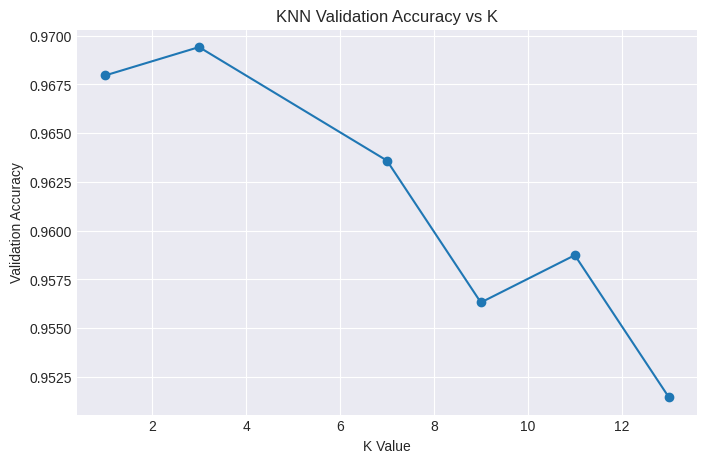

Best K selected: 3

Confusion Matrix (Test Data):
[[389   0   0   0   0   0]
 [  0 320  36   0   0   0]
 [  0  28 353   0   0   0]
 [  0   0   0 343   0   1]
 [  0   0   0   2 277   2]
 [  0   0   0   0   0 309]]


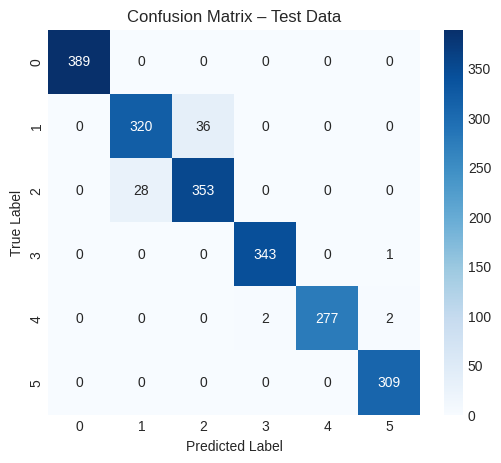


Test Set Performance
Accuracy: 0.9665
Precision (Macro): 0.9686
Precision (Micro): 0.9665
Recall (Macro): 0.9680
Recall (Micro): 0.9665
F1-score (Macro): 0.9683
F1-score (Micro): 0.9665


In [ ]:


# 1. Load Data

train_df = pd.read_csv("ActivityTrain.csv")
val_df   = pd.read_csv("ActivityValidation.csv")
test_df  = pd.read_csv("ActivityTest.csv")

# Assuming last column is the label
X_train, y_train = train_df.iloc[:, :-1], train_df.iloc[:, -1]
X_val, y_val     = val_df.iloc[:, :-1], val_df.iloc[:, -1]
X_test, y_test   = test_df.iloc[:, :-1], test_df.iloc[:, -1]


# 2–3. KNN Validation for Different K Values

k_values = [1, 3, 7, 9, 11, 13]
validation_results = []
acc_k=[]

print("KNN – Validation Results")
print("=" * 80)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_val_pred = knn.predict(X_val)

    acc        = accuracy_score(y_val, y_val_pred)
    prec_micro = precision_score(y_val, y_val_pred, average='micro')
    prec_macro = precision_score(y_val, y_val_pred, average='macro')
    rec_micro  = recall_score(y_val, y_val_pred, average='micro')
    rec_macro  = recall_score(y_val, y_val_pred, average='macro')
    f1_micro   = f1_score(y_val, y_val_pred, average='micro')
    f1_macro   = f1_score(y_val, y_val_pred, average='macro')

    validation_results.append({
        'K': k,
        'Accuracy': acc,
        'Precision_Micro': prec_micro,
        'Precision_Macro': prec_macro,
        'Recall_Micro': rec_micro,
        'Recall_Macro': rec_macro,
        'F1_Micro': f1_micro,
        'F1_Macro': f1_macro
    })
    acc_k.append(acc)
    print(f"K={k:2d} | Acc={acc:.4f} | "
          f"Prec(Macro)={prec_macro:.4f} | "
          f"Rec(Macro)={rec_macro:.4f} | "
          f"F1(Macro)={f1_macro:.4f}")

print("=" * 80)


# 4. Plot Accuracy vs K

val_results_df = pd.DataFrame(validation_results)

plt.figure(figsize=(8,5))
plt.plot(val_results_df['K'], val_results_df['Accuracy'], marker='o')
plt.xlabel('K Value')
plt.ylabel('Validation Accuracy')
plt.title('KNN Validation Accuracy vs K')
plt.grid(True)
plt.show()


# 5. Select Best K
best_k=k_values[np.argmax(acc_k)]
# best_k = val_results_df.loc[val_results_df['Accuracy'].idxmax(), 'K']
print(f"Best K selected: {best_k}")


# 6. Final Evaluation on Test Data

best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)

y_test_pred = best_knn.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix (Test Data):")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Test Data")
plt.show()

# Test Metrics
print("\nTest Set Performance")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision (Macro): {precision_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"Precision (Micro): {precision_score(y_test, y_test_pred, average='micro'):.4f}")
print(f"Recall (Macro): {recall_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"Recall (Micro): {recall_score(y_test, y_test_pred, average='micro'):.4f}")
print(f"F1-score (Macro): {f1_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"F1-score (Micro): {f1_score(y_test, y_test_pred, average='micro'):.4f}")


In [64]:
#PART:C


# 1. Load Data

train_df = pd.read_csv("ActivityScaledTrain.csv")
val_df   = pd.read_csv("ActivityScaledValidation.csv")
test_df  = pd.read_csv("ActivityScaledTest.csv")

# Assuming last column is the label
X_train, y_train = train_df.iloc[:, :-1], train_df.iloc[:, -1]
X_val, y_val     = val_df.iloc[:, :-1], val_df.iloc[:, -1]
X_test, y_test   = test_df.iloc[:, :-1], test_df.iloc[:, -1]


# 2–3. KNN Validation for Different K Values

k_values = [1, 3, 7, 9, 11, 13]
validation_results = []

print("KNN – Validation Results")
print("=" * 80)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_val_pred = knn.predict(X_val)

    acc        = accuracy_score(y_val, y_val_pred)
    prec_micro = precision_score(y_val, y_val_pred, average='micro')
    prec_macro = precision_score(y_val, y_val_pred, average='macro')
    rec_micro  = recall_score(y_val, y_val_pred, average='micro')
    rec_macro  = recall_score(y_val, y_val_pred, average='macro')
    f1_micro   = f1_score(y_val, y_val_pred, average='micro')
    f1_macro   = f1_score(y_val, y_val_pred, average='macro')

    validation_results.append({
        'K': k,
        'Accuracy': acc,
        'Precision_Micro': prec_micro,
        'Precision_Macro': prec_macro,
        'Recall_Micro': rec_micro,
        'Recall_Macro': rec_macro,
        'F1_Micro': f1_micro,
        'F1_Macro': f1_macro
    })

    print(f"K={k:2d} | Acc={acc:.4f} | "
          f"Prec(Macro)={prec_macro:.4f} | "
          f"Rec(Macro)={rec_macro:.4f} | "
          f"F1(Macro)={f1_macro:.4f}")

print("=" * 80)


# 4. Plot Accuracy vs K

val_results_df = pd.DataFrame(validation_results)

plt.figure(figsize=(8,5))
plt.plot(val_results_df['K'], val_results_df['Accuracy'], marker='o')
plt.xlabel('K Value')
plt.ylabel('Validation Accuracy')
plt.title('KNN Validation Accuracy vs K')
plt.grid(True)
plt.show()

# 5. Select Best K

best_k = val_results_df.loc[val_results_df['Accuracy'].idxmax(), 'K']
print(f"Best K selected: {best_k}")


# 6. Final Evaluation on Test Data

best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)

y_test_pred = best_knn.predict(X_test)

KNN – Validation Results


ValueError: Input X contains NaN.
KNeighborsClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values